# Frame Viewer
Loads images from a folder, sorts them by UUID v1 timestamp, and plays them as a video.

In [1]:
import cv2
import uuid
import os
import numpy as np
from pathlib import Path
from IPython.display import display, Image, clear_output
import time

In [111]:
# --- Configuration ---
FOLDER = Path("session_20260612_092229")   # change to any folder with .jpg/.png frames
FPS = 30                # playback frames per second
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

In [112]:
def uuid1_time(filename: str) -> int:
    """Return the 60-bit UUID v1 timestamp from a filename stem, or fall back to 0."""
    stem = Path(filename).stem
    try:
        u = uuid.UUID(stem)
        if u.version == 1:
            return u.time
    except (ValueError, AttributeError):
        pass
    return 0


def load_sorted_frames(folder: Path) -> list[Path]:
    """Return image paths sorted by UUID v1 timestamp (falls back to mtime)."""
    files = [p for p in folder.iterdir() if p.suffix.lower() in EXTENSIONS]
    # Try UUID v1 sort first; if all times are 0, fall back to mtime
    times = [uuid1_time(p.name) for p in files]
    if any(t > 0 for t in times):
        files.sort(key=lambda p: uuid1_time(p.name))
    else:
        files.sort(key=lambda p: p.stat().st_mtime)
    return files


frames = load_sorted_frames(FOLDER)
print(f"Found {len(frames)} frames in '{FOLDER}'")
if frames:
    print(f"  First: {frames[0].name}")
    print(f"  Last : {frames[-1].name}")

Found 87 frames in 'session_20260612_092229'
  First: 3be71588-6640-11f1-9f09-d8f8836d4d04.jpg
  Last : 3f5599ba-6640-11f1-9f09-d8f8836d4d04.jpg


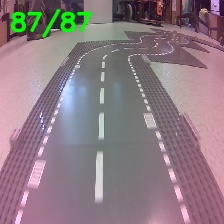

Playback complete.


In [113]:
def bgr_to_jpeg_bytes(bgr_img: np.ndarray) -> bytes:
    """Encode a BGR OpenCV image to JPEG bytes for inline display."""
    ok, buf = cv2.imencode(".jpg", bgr_img)
    if not ok:
        raise RuntimeError("cv2.imencode failed")
    return buf.tobytes()


frame_delay = 1.0 / FPS

for i, path in enumerate(frames):
    img = cv2.imread(str(path))
    if img is None:
        print(f"Could not read {path.name}, skipping")
        continue

    # Overlay frame counter
    cv2.putText(
        img,
        f"{i + 1}/{len(frames)}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

    clear_output(wait=True)
    display(Image(data=bgr_to_jpeg_bytes(img)))
    time.sleep(frame_delay)

print("Playback complete.")